In [66]:
import nltk
nltk.download('brown')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('treebank')
nltk.download('words')
nltk.download('ieer')
nltk.download('conll2000')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package ieer to /root/nltk_data...
[nltk_data]   Package ieer is already up-to-date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!


True

In [67]:
from nltk.chunk.util import conlltags2tree, tree2conlltags
from nltk.chunk import ChunkParserI
from nltk.tag import UnigramTagger, BigramTagger

In [68]:
from nltk.corpus import ieer, brown, treebank, conll2000

In [69]:
import re
from nltk.corpus import ieer
from nltk.sem import extract_rels


In [70]:
nltk.download('maxent_ne_chunker')


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!


True

In [71]:
pip install svgling


In [72]:
from nltk.corpus import brown

In [73]:
fiction=brown.words(categories='fiction')

In [74]:
sent=fiction[:20]

In [75]:
print(sent)

['Thirty-three', 'Scotty', 'did', 'not', 'go', 'back', 'to', 'school', '.', 'His', 'parents', 'talked', 'seriously', 'and', 'lengthily', 'to', 'their', 'own', 'doctor', 'and']


In [76]:
from nltk.tokenize import word_tokenize
from nltk import pos_tag

In [77]:
a=pos_tag(sent)
print(a)

[('Thirty-three', 'JJ'), ('Scotty', 'NNP'), ('did', 'VBD'), ('not', 'RB'), ('go', 'VB'), ('back', 'RB'), ('to', 'TO'), ('school', 'NN'), ('.', '.'), ('His', 'PRP$'), ('parents', 'NNS'), ('talked', 'VBD'), ('seriously', 'RB'), ('and', 'CC'), ('lengthily', 'RB'), ('to', 'TO'), ('their', 'PRP$'), ('own', 'JJ'), ('doctor', 'NN'), ('and', 'CC')]


In [78]:
grammar = "NP: {<JJ><NN>}"

In [79]:
cp = nltk.RegexpParser(grammar)

In [80]:
result = cp.parse(a)

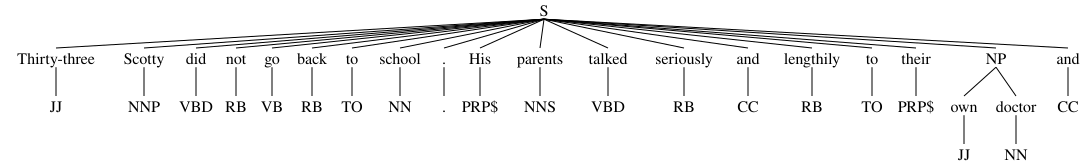

In [81]:
result


In [82]:
sent = nltk.corpus.treebank.tagged_sents()[22]
print(nltk.ne_chunk(a, binary=True))

(S
  Thirty-three/JJ
  (NE Scotty/NNP)
  did/VBD
  not/RB
  go/VB
  back/RB
  to/TO
  school/NN
  ./.
  His/PRP$
  parents/NNS
  talked/VBD
  seriously/RB
  and/CC
  lengthily/RB
  to/TO
  their/PRP$
  own/JJ
  doctor/NN
  and/CC)


In [83]:
print(nltk.ne_chunk(a))

(S
  Thirty-three/JJ
  (PERSON Scotty/NNP)
  did/VBD
  not/RB
  go/VB
  back/RB
  to/TO
  school/NN
  ./.
  His/PRP$
  parents/NNS
  talked/VBD
  seriously/RB
  and/CC
  lengthily/RB
  to/TO
  their/PRP$
  own/JJ
  doctor/NN
  and/CC)


In [84]:
IN = re.compile(r'.*\bin\b(?!\b.+ing)')
for doc in nltk.corpus.ieer.parsed_docs('APW_19980314'):
  for rel in nltk.sem.extract_rels('ORG', 'LOC', doc,corpus='ieer', pattern = IN):
    print(nltk.sem.rtuple(rel))

[ORG: 'Christian Democrats'] ', the leading political forces in' [LOC: 'Italy']
[ORG: 'AP'] ') _ Lebanese guerrillas attacked Israeli forces in southern' [LOC: 'Lebanon']
[ORG: 'Security Council'] 'adopted Resolution 425. Huge yellow banners hung across intersections in' [LOC: 'Beirut']


In [85]:
class UnigramChunker(ChunkParserI):
    def __init__(self, train_sents):
        train_data = [[(t, c) for w, t, c in nltk.chunk.tree2conlltags(sent)]
                      for sent in train_sents]
        self.tagger = UnigramTagger(train_data)

    def parse(self, sentence):
        pos_tags = [pos for (word, pos) in sentence]
        tagged_pos_tags = self.tagger.tag(pos_tags)
        conlltags = [(word, pos, chunk_tag) for ((word, pos), (pos2, chunk_tag))
                     in zip(sentence, tagged_pos_tags)]
        return conlltags2tree(conlltags)

train_sents = conll2000.chunked_sents('train.txt', chunk_types=['NP'])
test_sents = conll2000.chunked_sents('test.txt', chunk_types=['NP'])

unigram_chunker = UnigramChunker(train_sents)
print(unigram_chunker.evaluate(test_sents))

class BigramChunker(ChunkParserI):
    def __init__(self, train_sents):
        train_data = [[(t, c) for w, t, c in nltk.chunk.tree2conlltags(sent)]
                      for sent in train_sents]
        self.tagger = BigramTagger(train_data)

    def parse(self, sentence):
        pos_tags = [pos for (word, pos) in sentence]
        tagged_pos_tags = self.tagger.tag(pos_tags)
        conlltags = [(word, pos, chunk_tag) for ((word, pos), (pos2, chunk_tag))
                     in zip(sentence, tagged_pos_tags)]
        return conlltags2tree(conlltags)

bigram_chunker = BigramChunker(train_sents)
print(bigram_chunker.evaluate(test_sents))

<ipython-input-85-70df1885cc3b>:18: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  print(unigram_chunker.evaluate(test_sents))


ChunkParse score:
    IOB Accuracy:  92.9%%
    Precision:     79.9%%
    Recall:        86.8%%
    F-Measure:     83.2%%


<ipython-input-85-70df1885cc3b>:34: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  print(bigram_chunker.evaluate(test_sents))


ChunkParse score:
    IOB Accuracy:  93.3%%
    Precision:     82.3%%
    Recall:        86.8%%
    F-Measure:     84.5%%


In [86]:

grammar = r"""
  NP: {<DT|JJ|NN.*>+}
  PP: {<IN><NP>}
  VP: {<VB.*><NP|PP|CLAUSE>+$}
  CLAUSE: {<NP><VP>}  zx
  """
cp = nltk.RegexpParser(grammar)
test_sent = treebank.tagged_sents()[22]
print("Original Sentence:")
print(test_sent)
print("\nParsed Sentence:")
parsed_sentence = cp.parse(test_sent)
print(parsed_sentence)
def print_tree(tree, indent=0):
    for subtree in tree:
        if type(subtree) == nltk.Tree:
            print(' ' * indent + '(' + subtree.label())
            print_tree(subtree, indent + 2)
            print(' ' * indent + ')')
        else:
            print(' ' * indent + str(subtree))

print("\nFormatted Parsed Sentence:")
print_tree(parsed_sentence)


Original Sentence:
[('The', 'DT'), ('U.S.', 'NNP'), ('is', 'VBZ'), ('one', 'CD'), ('of', 'IN'), ('the', 'DT'), ('few', 'JJ'), ('industrialized', 'VBN'), ('nations', 'NNS'), ('that', 'WDT'), ('*T*-7', '-NONE-'), ('does', 'VBZ'), ("n't", 'RB'), ('have', 'VB'), ('a', 'DT'), ('higher', 'JJR'), ('standard', 'NN'), ('of', 'IN'), ('regulation', 'NN'), ('for', 'IN'), ('the', 'DT'), ('smooth', 'JJ'), (',', ','), ('needle-like', 'JJ'), ('fibers', 'NNS'), ('such', 'JJ'), ('as', 'IN'), ('crocidolite', 'NN'), ('that', 'WDT'), ('*T*-1', '-NONE-'), ('are', 'VBP'), ('classified', 'VBN'), ('*-5', '-NONE-'), ('as', 'IN'), ('amphobiles', 'NNS'), (',', ','), ('according', 'VBG'), ('to', 'TO'), ('Brooke', 'NNP'), ('T.', 'NNP'), ('Mossman', 'NNP'), (',', ','), ('a', 'DT'), ('professor', 'NN'), ('of', 'IN'), ('pathlogy', 'NN'), ('at', 'IN'), ('the', 'DT'), ('University', 'NNP'), ('of', 'IN'), ('Vermont', 'NNP'), ('College', 'NNP'), ('of', 'IN'), ('Medicine', 'NNP'), ('.', '.')]

Parsed Sentence:
(S
  (NP The